In [ ]:
import sys
from matplotlib import pyplot as plt
import numpy as np
import os
from time import perf_counter
from pathlib import Path
sys.path.append(r"C:\\CODE_FOLDER\\enigma2\\src\\enigma2")
# sys.path.append(r"c:\\CODE_FOLDER\\enigma2\\src\\e2_config")
from enigma2 import E2, E2Config
# from e2_config import E2Config
import pprint
import re
from pathlib import Path

pwd = b"example_pwd"
config_data = E2Config(pwd=pwd)
config_data.verbose = False
pprint.pprint(config_data)

In [7]:
# wrapper timer
def time_func(func):
    def wrapper(*args, **kwargs):
        start = perf_counter()
        result = func(*args, **kwargs)
        end = perf_counter()
        # print(f"{func.__name__} took {end - start:.4f} seconds")
        return result, end-start
    return wrapper

In [ ]:

class statsFile:
    
    def __init__(self, path=None, **kwargs):
        """
        Class to store and generate stats for Enigma2
        
        Parameters
        ----------
        path : str or None, optional
            Path to a file containing stats data. If None, it will generate stats for Enigma2
        **kwargs
            Keyword arguments to pass to E2Config:
            - data_unit: str, optional
            - data_max_size: int, optional
            - data_min_size: int, optional
            - data_reps: int, optional
            - st_file.sample_len: int, optional
            - currpath: Path, optional
            
        Returns
        -------
        statsFile object
        """

        self.valid_data_units = {"bytes":1, 
                                 "kb":1024, 
                                 "mb":1024**2, 
                                 "gb": 1024**3}

        if path is None:
            data_unit = kwargs.get("data_unit", "mb")
            if data_unit not in self.valid_data_units:
                raise ValueError
            data_unit_int = self.valid_data_units[data_unit]
            data_max_size = kwargs.get("data_max_size", None)
            if data_max_size is None:
                raise ValueError

            data_min_size = kwargs.get("data_min_size", None)
            if data_min_size is None:
                raise ValueError
            
            data_reps = kwargs.get("data_reps", None)
            if data_reps is None:
                raise ValueError
            sample_len = kwargs.get("st_file.sample_len", None)
            if sample_len is None:
                raise ValueError
            
            currpath = kwargs.get("currpath", Path(__file__).parent)
            path = Path(currpath).joinpath(f"test_data{data_min_size}to{data_max_size}{data_unit}{data_reps}reps{sample_len}.npy")
        else:
            path_name = Path(path).name
            regex = r"^test_data(?P<data_min_size>\d+)to(?P<data_max_size>\d+)(?P<data_unit>[bytes|kb|mb|gb])(?P<data_reps>\d+)reps(?P<sample_len>\d+>).npy$"
            match = re.match(regex, path_name)
            if match:
                data_min_size = match.group("data_min_size")
                data_max_size = match.group("data_max_size")
                data_unit = match.group("data_unit")
                data_reps = match.group("data_reps")
                sample_len = match.group("st_file.sample_len")
            else:
                raise ValueError(f"No match: {path}")

        self.path = path
        self.exists = self.path.exists()
        self.data_unit = data_unit
        self.data_unit_int = self.valid_data_units[data_unit]
        self.data_min_size = data_min_size
        self.data_min_size_bytes = data_min_size*self.data_unit_int
        self.data_max_size = data_max_size
        self.data_max_size_bytes = data_max_size*self.data_unit_int
        self.data_reps = data_reps
        self.sample_len = sample_len
        self.currpath = currpath


    def get_path(self) -> Path:
        return self.path

    def upload_file(self) -> np.array:
        return np.load(self.path)

    def save_file(self, data_array: np.array) -> Path:
        np.save(self.path, data_array)
        return self.path

E2Config({'_E2Config__main_seeds_len': 24, '_E2Config__seeds_number': 5, 'hash_alg': 'sha3_512', 'pwd': b'example_pwd', 'hash_pwd': 'a69f73cca23a9ac5c8b567dc185a756e97c982164fe25859e0d1dcc1475c80a615b2123af1f5f94c11e3e9402c3ac558f500199d95b6d3e301758586281dcd26', 'dtype2btype': {<class 'numpy.uint8'>: 256, <class 'numpy.uint16'>: 65536, <class 'numpy.uint32'>: 4294967296, <class 'numpy.uint64'>: 18446744073709551616}, 'dtype': <class 'numpy.uint8'>, 'btype': 256, 'rotations_seed': 51567277682633154450100152284, 'number_rotors': 16, 'number_rotations': 16, 'rotors_seed': 7536998116435358334046066777, 'plugboard_seed': 69578350182270716765122204218, 'plugboard_size': 6, 'noise_size': 32471587243600040987863889861842, 'noise_seed': 74883251465245660234246702424, 'original_rotations': False, 'start_op_index': 0, 'avoid_validation': False, 'verbose': False, 'log_path': None, 'encoding': 'utf-8'})


In [ ]:

# st_file.sample_len = 200
# DATA_MAX_LEN = 1024**2*st_file.sample_len
# DATA_MIN_LEN = 1024**2
# st_file.data_reps = 5
CURRPATH = "C:\\CODE_FOLDER\\enigma2\\statistics\\analytics"

e2 = E2(config=config_data)
rng = np.random.default_rng(1700)

# st_file = statsFile(**{
#     "data_min_size": 1,
#     "data_max_size": 10,
#     "data_unit": "mb",
#     "data_reps": 5,
#     "st_file.sample_len": 10,
#     "currpath": CURRPATH
# })# "C:\\CODE_FOLDER\\enigma2\\tests\\test_data200mb5reps.npy"
st_file = statsFile(path=f"{CURRPATH}\\test_data1to100mb5reps100.npy")

"""
DATA ARRAY SCHEME: (csv-like array)

[
[0.3, 1.0, 2.0, 3.0, 4.0, ...] # encryption times sample 1
[0.1, 1.1, 1.3, 3.4, 4.5, ...] # encryption times sample 2
[0.3, 1.0, 2.0, 3.0, 4.0, ...] # encryption times sample 3
...
[0.3, 1.0, 2.0, 3.0, 4.0, ...] # encryption times sample st_file.sample_len
---
[0.4, 1.0, 2.0, 3.0, 4.0, ...] # decryption times sample 1
[0.1, 1.1, 1.3, 3.4, 4.5, ...] # decryption times sample 2
[0.3, 1.0, 2.0, 3.0, 4.0, ...] # decryption times sample 3
...
[0.3, 1.0, 2.0, 3.0, 4.0, ...] # decryption times sample st_file.sample_len
]
"""

# metadata = [st_file.st_file.sample_len, DATA_MIN_LEN, DATA_MAX_LEN, st_file.data_reps]

memo_array = np.arange(1, st_file.sample_len+1, dtype=np.uint64)
time_array_encr = np.empty(shape=(st_file.data_reps, st_file.sample_len), dtype=np.float32)
time_array_decr = np.empty_like(time_array_encr, dtype=np.float32)

@time_func
def encr(cipher: E2, data: np.array) -> np.array:
    return cipher.encrypt(data)

@time_func
def decr(cipher: E2, data: np.array) -> np.array:
    return cipher.decrypt(data)

REWRITE_FILE = False

# TODO: save data on csv, json, np.array ...
if REWRITE_FILE or not st_file.exists:
    for sample_num in range(st_file.sample_len):
        for rep in range(st_file.data_reps):
            print(f"\rSample {sample_num+1}/{st_file.sample_len} {rep+1}/{st_file.data_reps}", end="")
            data_array = np.frombuffer(os.urandom(memo_array[sample_num]*st_file.data_unit_int), dtype=config_data.dtype)# rng.integers(0, config_data.btype, memo_array[i], dtype=config_data.dtype)
            data, tm_encr = encr(e2, data_array)
            _, tm_decr = decr(e2, data)
            time_array_encr[rep][sample_num], time_array_decr[rep][sample_num] = tm_encr, tm_decr
    # np.save(path, np.vstack((time_array_encr, time_array_decr)))
    st_file.save_file(data=np.vstack((time_array_encr, time_array_decr)).copy())

else:
    data = st_file.upload_file()
    print(data.shape, data.dtype)
    # st_file.sample_len = data.shape[1]
    # st_file.sample_len, DATA_MIN_LEN, DATA_MAX_LEN, st_file.data_reps = data.shape[1], 1024**2, 1024**2*data.shape[1], data.shape[0]//2
    memo_array = np.arange(1, st_file.sample_len+1, dtype=np.uint64)
    time_array_encr = data[:st_file.data_reps].copy()
    time_array_decr = data[st_file.data_reps: st_file.data_reps*2].copy()
    print(time_array_encr.shape, time_array_decr.shape)


ValueError: No match: C:\CODE_FOLDER\enigma2\statistics\analytics\test_data1to100mb5reps100.npy

1000 1000


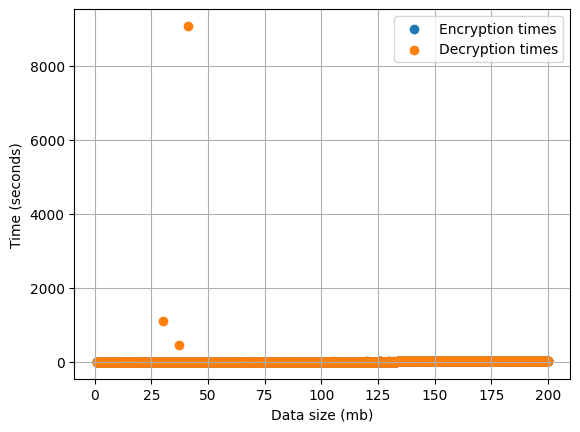

In [ ]:
# find the line on the plane that best fits the data
mean_time_arrays_encr = np.mean(time_array_encr, axis=0)
mean_time_arrays_decr = np.mean(time_array_decr, axis=0)

xarray = np.empty_like(time_array_encr)
for i in range(st_file.sample_len):
    xarray[:, i] = memo_array[i]
xarray = xarray.reshape(-1)

xmean_array = memo_array

print(xarray.size, time_array_encr.size)
plt.grid(True)
plt.scatter(xarray, time_array_encr.reshape(-1))
plt.scatter(xarray, time_array_decr.reshape(-1))
# plt.plot(xmean_array, mean_time_arrays_encr)
# plt.plot(xmean_array, mean_time_arrays_decr)
plt.legend([
    "Encryption times", 
    "Decryption times", 
    # "Encryption mean times", 
    # "Decryption mean times",
    ])

plt.xlabel(f"Data size ({st_file.data_unit})")
plt.ylabel("Time (seconds)")
plt.show()